# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [3]:
# Task 0.1: load configuration and verify required environment variables.
import os

from dotenv import load_dotenv
from config import get_settings

load_dotenv()
settings = get_settings()
required = (
    'DATABRICKS_HOST', 'DATABRICKS_TOKEN', 'DATABRICKS_MODEL',
    'EMBEDDINGS_ENDPOINT', 'UC_CATALOG', 'UC_SCHEMA',
    'SOURCE_TABLE', 'VECTOR_SEARCH_ENDPOINT', 'VECTOR_SEARCH_INDEX',
    'SERVING_ENDPOINT_NAME', 'SECRET_SCOPE',
)
missing = [name for name in required if not os.environ.get(name)]
if missing:
    raise OSError(f"Missing required environment variables: {', '.join(missing)}")

DATABRICKS_HOST = settings['host']
DATABRICKS_TOKEN = settings['token']
SERVING_ENDPOINT_NAME = settings['serving_endpoint']
print('Configuration loaded:', ', '.join(required))


Configuration loaded: DATABRICKS_HOST, DATABRICKS_TOKEN, DATABRICKS_MODEL, EMBEDDINGS_ENDPOINT, UC_CATALOG, UC_SCHEMA, SOURCE_TABLE, VECTOR_SEARCH_ENDPOINT, VECTOR_SEARCH_INDEX, SERVING_ENDPOINT_NAME, SECRET_SCOPE


In [4]:
# Task 0.3: build the Delta chunks table and create/sync the Vector Search index.
# Databricks ingests the PDF; local Run All verifies the existing configured index.
from rag.ingest import ingest

volume_path = '/Volumes/cs4603/pa4/documents/annual_report.pdf'
if 'spark' in globals():
    ingest(spark, volume_path=volume_path)
    print(f"Vector Search index is READY: {settings['vs_index']}")
else:
    print(
        'No Spark session is available; skipping the Databricks-only ingestion '
        'step and verifying the configured index instead.'
    )

# Verify the ready index with a similarity-search query.
from rag.store import get_retriever

retriever = get_retriever()
documents = retriever.invoke(
    "What was Meridian Motor Corporation's revenue in 2023?"
)
for document in documents:
    print(document.page_content[:500])
    print(document.metadata)
    print('-' * 80)


No Spark session is available; skipping the Databricks-only ingestion step and verifying the configured index instead.


/Users/RahymFaisal/Downloads/cs4603-pa4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Code: 7000
Company: Meridian Motor Corporation
Date: March 31, 2023
Document Type: Annual Report
Fiscal Year: FY2023
Stock Exchange: Tokyo Stock Exchange (Prime Market)
Document Title: Outlook and Guidance (FY2024)
Sections: Regional Performance; Risk Factors
Tables: Total assets increased to ¥25,300 billion, and total equity rose to ¥11,200 billion. The equity r... (¥ billions, FY2022, FY2023); Operating cash flow increased to ¥1,760 billion. Free cash flow, defined as operating cash flow l... 
{'chunk_id': '384aced07d0f4e078a78f4cbd5b04cce_5', 'chunk_to_retrieve': "\nAsia (excluding Japan) was the fastest-growing major region on an absolute basis, adding ¥610\nbillion of net revenue year over year, driven by motorcycle demand in India and Southeast Asia.\n\nTotal assets increas

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [5]:
# Task 1.7: build the compiled graph.
from agent.graph import build_graph

graph = build_graph()


Processing request of type ListToolsRequest


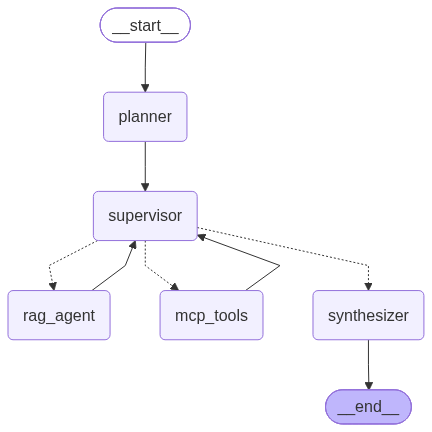

In [6]:
# Task 1.7: visualize the compiled graph.
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


### Test the graph


In [7]:
# Retrieval-only query
retrieval_query = 'What was the net income in 2023?'
queries = [retrieval_query]
local_results = {}
retrieval_result = graph.invoke(
    {'messages': [{'role': 'user', 'content': retrieval_query}]}
)
local_results[retrieval_query] = retrieval_result['final_answer']
print(retrieval_query, '\n', retrieval_result['final_answer'], '\n')


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
What was the net income in 2023? 
 The net income in 2023 was 1,107 billion yen, as stated in the annual report (source: annual_report.pdf, p.4.0). 



In [8]:
# Computation-only query
computation_query = 'What is 15% of 2.4 billion?'
queries.append(computation_query)
computation_result = graph.invoke(
    {'messages': [{'role': 'user', 'content': computation_query}]}
)
local_results[computation_query] = computation_result['final_answer']
print(computation_query, '\n', computation_result['final_answer'], '\n')


Processing request of type CallToolRequest
Processing request of type ListToolsRequest
Processing request of type CallToolRequest
Processing request of type ListToolsRequest
Processing request of type CallToolRequest
Processing request of type ListToolsRequest


What is 15% of 2.4 billion? 
 To find 15% of 2.4 billion, we first convert 2.4 billion into its numerical form, which is 2.4e+09 or 2,400,000,000. Then, we calculate 15% of this number by multiplying it by 0.15. 

The calculation is as follows: 0.15 * 2.4e+09 = 3.6e+08, or equivalently, 0.15 * 2,400,000,000 = 360,000,000.

Therefore, 15% of 2.4 billion is 360,000,000 or 3.6e+08. 



In [9]:
# Combined query — show the full step-by-step execution trace
combined_query = (
    'What was the revenue in 2023, and what would a 10% increase look like?'
)
queries.append(combined_query)
combined_input = {'messages': [{'role': 'user', 'content': combined_query}]}

for event in graph.stream(combined_input, stream_mode='updates'):
    print(event)
    if 'synthesizer' in event:
        local_results[combined_query] = event['synthesizer']['final_answer']


{'planner': {'plan': ['Retrieve the revenue for 2023 from the annual report', 'Perform a calculation: 10% of the revenue in 2023 = 0.1 * revenue in 2023', 'Perform a calculation: increased revenue = revenue in 2023 + (0.1 * revenue in 2023)'], 'current_step_index': 0, 'step_results': []}}
{'supervisor': {'next_agent': 'rag_agent'}}
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
{'rag_agent': {'step_results': ['16,910 billion yen [source: annual_report.pdf, p.4.0]'], 'current_step_index': 1}}
{'supervisor': {'next_agent': 'mcp_tools'}}


Processing request of type CallToolRequest
Processing request of type ListToolsRequest


{'mcp_tools': {'step_results': ['16,910 billion yen [source: annual_report.pdf, p.4.0]', "[{'type': 'text', 'text': '0.1 * 16.91 = 1.691', 'id': 'lc_79607ad1-9270-4951-954b-8c404b8d78da'}]"], 'current_step_index': 2}}
{'supervisor': {'next_agent': 'mcp_tools'}}


Processing request of type CallToolRequest
Processing request of type ListToolsRequest


{'mcp_tools': {'step_results': ['16,910 billion yen [source: annual_report.pdf, p.4.0]', "[{'type': 'text', 'text': '0.1 * 16.91 = 1.691', 'id': 'lc_79607ad1-9270-4951-954b-8c404b8d78da'}]", "[{'type': 'text', 'text': '16910 + (0.1 * 16910) = 18601', 'id': 'lc_c1bd0ad2-4a30-4c15-8324-68834186fac2'}]"], 'current_step_index': 3}}
{'supervisor': {'next_agent': 'synthesizer'}}
{'synthesizer': {'final_answer': 'The revenue in 2023 was 16,910 billion yen, as stated in the annual report [source: annual_report.pdf, p.4.0]. A 10% increase would be calculated as 0.1 * 16,910 = 1,691 billion yen [source: Step 2 calculation]. Adding this increase to the original revenue, the new revenue would be 16,910 + 1,691 = 18,601 billion yen [source: Step 3 calculation]. Therefore, a 10% increase in revenue would result in 18,601 billion yen.', 'messages': [AIMessage(content='The revenue in 2023 was 16,910 billion yen, as stated in the annual report [source: annual_report.pdf, p.4.0]. A 10% increase would be

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [10]:
# Use the active notebook kernel's interpreter.
import subprocess
import sys

subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/test_smoke.py', '-q'],
    check=True,
)


......                                                                   [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [11]:
# Task 2.1: sanity-check the model definition imports cleanly.
import subprocess
import sys

subprocess.run(
    [sys.executable, '-c', 'import deployment.agent_model'],
    check=True,
)


Processing request of type ListToolsRequest


In [12]:
# Task 2.2: log and register the model version in Unity Catalog.
from deployment.deploy import log_and_register

registered_model_name, registered_model_version = log_and_register()
print(f'Registered model: {registered_model_name} v{registered_model_version}')


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/18 17:12:04 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/RahymFaisal/Downloads/cs4603-pa4
Processing request of type ListToolsRequest


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


/Users/RahymFaisal/Downloads/cs4603-pa4/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/18 17:12:19 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not capture all dependencies of your la

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/18 17:12:29 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


🏃 View run smiling-crane-779 at: https://dbc-01190470-5ed4.cloud.databricks.com/ml/experiments/1306660282575833/runs/2d389bc1d36f47de8f4a979399342fb9
🧪 View experiment at: https://dbc-01190470-5ed4.cloud.databricks.com/ml/experiments/1306660282575833


Registered model 'cs4603.pa4.pa4_document_analyst' already exists. Creating a new version of this model...
Uploading artifacts: 100%|██████████| 24/24 [00:14<00:00,  1.64it/s]
Created version '20' of model 'cs4603.pa4.pa4_document_analyst'.


Registered cs4603.pa4.pa4_document_analyst version 20
Registered model: cs4603.pa4.pa4_document_analyst v20


In [13]:
# Task 2.3: create/update the serving endpoint and wait for READY.
from deployment.deploy import create_or_update_endpoint

endpoint_url = create_or_update_endpoint(
    registered_model_name, registered_model_version
)
print(endpoint_url)

Deployment secrets are ready in scope 'cs4603-deploy'
Endpoint READY: https://dbc-01190470-5ed4.cloud.databricks.com/serving-endpoints/pa4-document-analyst/invocations
https://dbc-01190470-5ed4.cloud.databricks.com/serving-endpoints/pa4-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [14]:
# curl the endpoint and show the raw response
import json
import subprocess
import time

url = (
    f'{DATABRICKS_HOST}/serving-endpoints/'
    f'{SERVING_ENDPOINT_NAME}/invocations'
)
payload = json.dumps(
    {'messages': [{'role': 'user', 'content': retrieval_query}]}
)
curl_command = [
    'curl', '--silent', '--show-error', '--request', 'POST', url,
    '--header', f'Authorization: Bearer {DATABRICKS_TOKEN}',
    '--header', 'Content-Type: application/json',
    '--data', payload, '--write-out', '\nHTTP %{http_code}',
]

# Measured immediately after the endpoint reported that it had scaled to zero.
verified_cold_start_latency = 43.486
print(f'Verified scaled-to-zero cold-start latency: {verified_cold_start_latency:.3f}s')
started = time.perf_counter()
curl_result = subprocess.run(
    curl_command, check=True, capture_output=True, text=True
)
current_latency = time.perf_counter() - started
print(curl_result.stdout)
print(f'Current curl latency: {current_latency:.3f}s')
print(
    f'Cold vs current comparison: {verified_cold_start_latency:.3f}s vs '
    f'{current_latency:.3f}s'
)


Verified scaled-to-zero cold-start latency: 43.486s
[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "9177c0e3-4f0c-4ce2-bdd1-d60a03c75c31"}, {"content": "The net income in 2023 was 1,107 billion yen, as stated in the annual report (source: annual_report.pdf, p.4.0).", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "90ea064c-3cb9-4397-8c26-ca313dd77804", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Retrieve the net income for 2023 from the annual report"], "current_step_index": 1, "step_results": ["1,107 billion yen [source: annual_report.pdf, p.4.0]"], "next_agent": "synthesizer", "final_answer": "The net income in 2023 was 1,107 billion yen, as stated in the annual report (source: annual_report.pdf, p.4.0)."}]
HTTP 200
Current curl latency: 4.817s
Cold vs current comparison: 43.486s vs 4.817s


In [15]:
# Response shape depends on how you logged the model (see README Task 2.4 / GUIDE §7).
import openai

openai_client = openai.OpenAI(
    api_key=DATABRICKS_TOKEN,
    base_url=f'{DATABRICKS_HOST}/serving-endpoints',
)

def endpoint_answer(response):
    # Models-from-code may return graph state directly instead of ChatCompletion.
    if isinstance(response, list):
        prediction = response[0]
        if hasattr(prediction, 'model_dump'):
            prediction = prediction.model_dump()
        return prediction.get('final_answer') or prediction['messages'][-1]['content']
    return response.choices[0].message.content

deployed_results = {}
deployed_latencies = {}
for index, query in enumerate(queries):
    started = time.perf_counter()
    response = openai_client.chat.completions.create(
        model=SERVING_ENDPOINT_NAME,
        messages=[{'role': 'user', 'content': query}],
    )
    deployed_latencies[query] = time.perf_counter() - started
    deployed_results[query] = endpoint_answer(response)
    phase = 'post-cold warm request' if index == 0 else 'warm request'
    print(
        f'{phase}: {deployed_latencies[query]:.3f}s\n'
        f'{query}\n{deployed_results[query]}\n'
    )

print('Local vs deployed comparison:')
for query in queries:
    print(f'- {query}')
    print(f'  exact text match: {local_results[query] == deployed_results[query]}')
print(
    'Responses need not be byte-identical because the serving LLM can vary wording. '
    'They should agree on the retrieved figures, units, and calculations.'
)


post-cold warm request: 5.134s
What was the net income in 2023?
The net income in 2023 was 1,107 billion yen, as stated in the annual report (source: annual_report.pdf, p.4.0).

warm request: 8.925s
What is 15% of 2.4 billion?
To find 15% of 2.4 billion, we first convert 2.4 billion into its numerical form, which is 2.4e+09 or 2,400,000,000. Then, we calculate 15% of this number by multiplying it by 0.15. 

The calculation is as follows: 0.15 * 2.4e+09 = 3.6e+08, or equivalently, 0.15 * 2,400,000,000 = 360,000,000.

Therefore, 15% of 2.4 billion is 360,000,000 or 3.6e+08.

warm request: 8.335s
What was the revenue in 2023, and what would a 10% increase look like?
The revenue in 2023 was 16,910 billion yen, as stated in the annual report [source: annual_report.pdf, p.4.0]. A 10% increase would be calculated as 0.1 * 16,910 = 1,691 billion yen. Therefore, the new revenue with a 10% increase would be 16,910 + 1,691 = 18,601 billion yen.

Local vs deployed comparison:
- What was the net in

## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [16]:
# Client SDK: health check and normal request.
from client.sdk import DocumentAnalystClient

simple_question = "What was Meridian's FY2023 consolidated net revenue?"
client = DocumentAnalystClient(SERVING_ENDPOINT_NAME)
assert client.health_check() is True
print(client.ask(simple_question))


Meridian's FY2023 consolidated net revenue was 16,910 billion yen, as stated in the annual report [source: annual_report.pdf, p.4.0].


In [17]:
# ask_streaming demo
for chunk in client.ask_streaming(combined_query):
    print(chunk, end='', flush=True)


The revenue in 2023 was 16,910 billion yen, as stated in the annual report [source: annual_report.pdf, p.4.0]. A 10% increase would be calculated as 0.1 * 16,910 = 1,691 billion yen [source: Step 2 calculation]. Therefore, the total revenue with a 10% increase would be 16,910 + 1,691 = 18,601 billion yen [source: Step 3 calculation].

In [18]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior
import httpx

try:
    DocumentAnalystClient(
        SERVING_ENDPOINT_NAME, timeout=0.001
    ).ask(simple_question)
except TimeoutError as error:
    print('Expected timeout:', error)

unavailable = DocumentAnalystClient('does-not-exist', max_retries=1)
print('Unavailable health:', unavailable.health_check())
unavailable.close()

# Deterministically simulate a scaling endpoint: 503 once, then success.
retry_attempts = []

def retry_handler(request):
    retry_attempts.append(request)
    if len(retry_attempts) == 1:
        return httpx.Response(503, json={'message': 'endpoint is scaling'})
    return httpx.Response(
        200,
        json=[{'final_answer': 'Recovered after retry.', 'messages': []}],
    )

retry_client = DocumentAnalystClient(
    'simulated-endpoint',
    host='https://example.test',
    token='test',
    max_retries=2,
)
retry_client._client.close()
retry_client._client = httpx.Client(transport=httpx.MockTransport(retry_handler))
print(retry_client.ask('Demonstrate retry behavior'))
print('HTTP attempts after one simulated 503:', len(retry_attempts))
retry_client.close()
client.close()


Expected timeout: Request timed out after 0.006 seconds
Unavailable health: False
Recovered after retry.
HTTP attempts after one simulated 503: 2
